In [26]:
from pathlib import Path
import pandas as pd

freqs = ['1d', '12h', '8h', '6h', '4h', '2h', '1h', '30m', '15m', '5m', '3m', '1m']
atrs = [i for i in range(50, 1000, 50)]


all_best_scores = []

for atr in atrs:
    data_dir = Path(f'./data/{atr}')
    for freq in freqs:
        file_path = data_dir / f'{freq}_bounce_data.csv'
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            
            # Find the best row
            best_idx = df['bounce_perc'].idxmin()
            best_row = df.loc[[best_idx]].copy() # Using [[]] keeps it as a DataFrame
            
            # Add metadata columns
            best_row['atr_param'] = atr
            best_row['frequency'] = freq
            
            all_best_scores.append(best_row)

# Combine everything into one master DataFrame
final_leaderboard = pd.concat(all_best_scores, ignore_index=True)

# Sort by score
final_leaderboard = final_leaderboard.sort_values('bounce_perc', ascending=True)

In [27]:
final_leaderboard.head(20)

,Unnamed: 0,Rolling_Window,Bounces,Penetrations,total,bounce_perc,atr_param,frequency
0,0,2,0,0,0,0.0,50,1d
1,0,2,0,3,3,0.0,50,12h
2,4,6,0,0,0,0.0,50,8h
3,4,6,0,1,1,0.0,50,6h
4,5,7,0,0,0,0.0,50,4h
5,19,21,0,7,7,0.0,50,2h
6,55,57,0,3,3,0.0,50,1h
15,9,11,0,3,3,0.0,100,6h
13,0,2,0,2,2,0.0,100,12h
14,4,6,0,0,0,0.0,100,8h


In [1]:
from pathlib import Path
import pandas as pd

freqs = ['1d', '12h', '8h', '6h', '4h', '2h', '1h', '30m', '15m', '5m', '3m', '1m']
atrs = [i for i in range(50, 1000, 50)]


all_best_scores = []

for atr in atrs:
    data_dir = Path(f'./data/{atr}')
    for freq in freqs:
        file_path = data_dir / f'{freq}_bounce_data.csv'
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['score'] = atr * (2 * df['bounce_perc'] - 100) * df['total']
            
            # Find the best row
            best_idx = df['score'].idxmax()
            best_row = df.loc[[best_idx]].copy() # Using [[]] keeps it as a DataFrame
            
            # Add metadata columns
            best_row['atr_param'] = atr
            best_row['frequency'] = freq
            
            all_best_scores.append(best_row)

# Combine everything into one master DataFrame
final_leaderboard = pd.concat(all_best_scores, ignore_index=True)

# Sort by score
final_leaderboard = final_leaderboard.sort_values('score', ascending=False)

In [9]:
final_leaderboard.head(20)

,Unnamed: 0,Rolling_Window,Bounces,Penetrations,total,bounce_perc,score,atr_param,frequency
227,412,414,599,69,668,89.670659,50350000.0,950,1m
215,394,396,631,76,707,89.250354,49950000.0,900,1m
203,415,417,634,75,709,89.421721,47515000.0,850,1m
191,364,366,670,88,758,88.390501,46560000.0,800,1m
155,175,177,829,153,982,84.419552,43940000.0,650,1m
179,264,266,685,108,793,86.380832,43275000.0,750,1m
143,157,159,883,164,1047,84.336199,43140000.0,600,1m
131,169,171,950,172,1122,84.670232,42790000.0,550,1m
167,187,189,743,140,883,84.144960,42210000.0,700,1m
119,150,152,1016,201,1217,83.483977,40750000.0,500,1m


In [7]:
from pathlib import Path
import pandas as pd

freqs = ['1d', '12h', '8h', '6h', '4h', '2h', '1h', '30m', '15m', '5m', '3m', '1m']
atrs = [i for i in range(50, 1000, 50)]


all_best_scores = []

for atr in atrs:
    data_dir = Path(f'./data/{atr}')
    for freq in freqs:
        file_path = data_dir / f'{freq}_bounce_data.csv'
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['score'] = atr * (100 - 2 * df['bounce_perc']) * df['total']
            
            # Find the best row
            best_idx = df['score'].idxmax()
            best_row = df.loc[[best_idx]].copy() # Using [[]] keeps it as a DataFrame
            
            # Add metadata columns
            best_row['atr_param'] = atr
            best_row['frequency'] = freq
            
            all_best_scores.append(best_row)

# Combine everything into one master DataFrame
final_pen_leaderboard = pd.concat(all_best_scores, ignore_index=True)

# Sort by score
final_pen_leaderboard = final_pen_leaderboard.sort_values('score', ascending=False)

In [10]:
final_pen_leaderboard.head(20)

,Unnamed: 0,Rolling_Window,Bounces,Penetrations,total,bounce_perc,score,atr_param,frequency
11,2,4,3417,4360,7777,43.937251,4715000.0,50,1m
23,2,4,2265,2661,4926,45.980512,3960000.0,100,1m
22,1,3,1062,1396,2458,43.205858,3340000.0,100,3m
33,2,4,593,761,1354,43.796160,2520000.0,150,5m
34,3,5,910,1066,1976,46.052632,2340000.0,150,3m
21,2,4,678,904,1582,42.857143,2260000.0,100,5m
10,1,3,1232,1646,2878,42.807505,2070000.0,50,3m
45,4,6,504,603,1107,45.528455,1980000.0,200,5m
35,1,3,1078,1180,2258,47.741364,1530000.0,150,1m
67,4,6,86,134,220,39.090909,1440000.0,300,30m


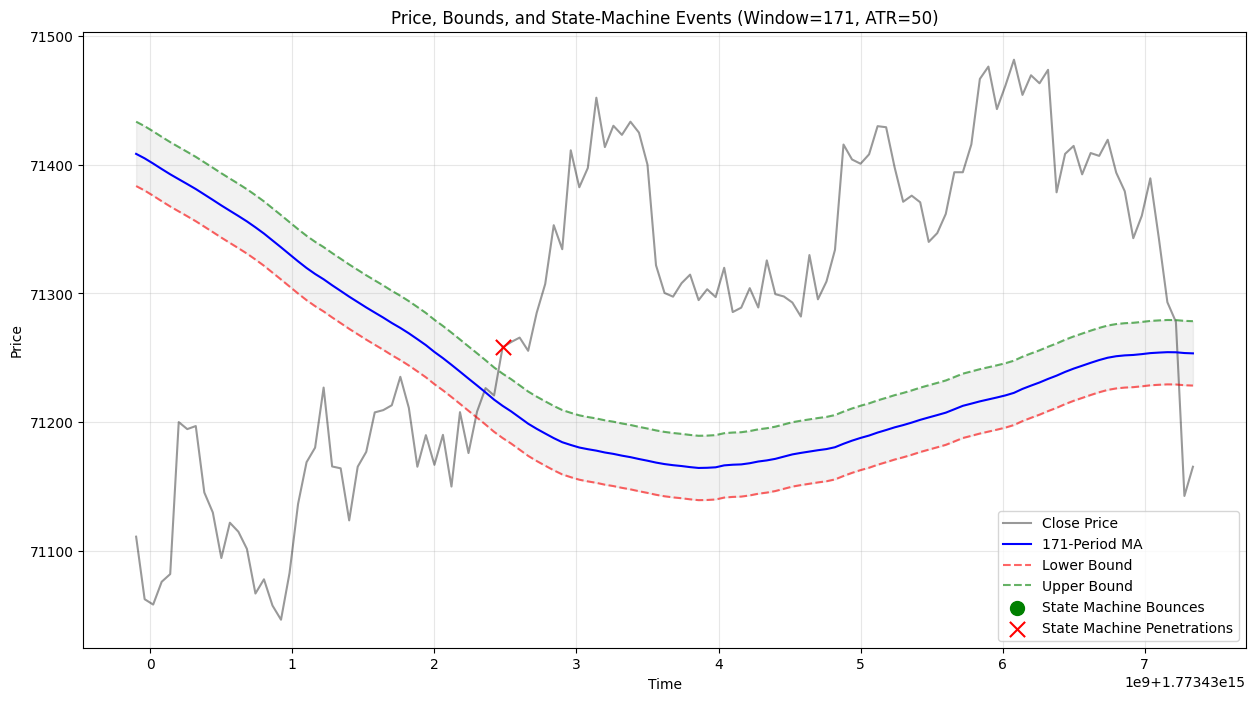

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from bounce_percentages import calculate_market_events
import glob
import os

# Parameters
atr = 50
rw = 171  # Example window size
freq = '1m'

path = f'/home/ora/Desktop/luma/almaty-lake-capital/bot/data/data/spot/daily/klines/BTCUSDT/1m/2026-01-11_2026-03-13'


all_files = glob.glob(os.path.join(path, "*.csv"))
cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 
        'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 
        'taker_buy_quote_asset_volume', 'ignore']
# Data Loading
df_list = [pd.read_csv(f, header=None, names=cols) for f in all_files]
df = pd.concat(df_list, ignore_index=True)
df = df.sort_values('open_time').reset_index(drop=True)

# Calculations
ma = df['close'].rolling(window=rw).mean()
ma = ma[-275:-150]
df=df[-275:-150]
l_bound = ma - atr * 0.5
u_bound = ma + atr * 0.5

bounce_indices, pen_indices = calculate_market_events(df['close'], l_bound, u_bound, rw)

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(df['open_time'], df['close'], label='Close Price', color='black', alpha=0.4)
plt.plot(df['open_time'], ma, label=f'{rw}-Period MA', color='blue', linewidth=1.5)
plt.plot(df['open_time'], l_bound, label='Lower Bound', color='red', linestyle='--', alpha=0.6)
plt.plot(df['open_time'], u_bound, label='Upper Bound', color='green', linestyle='--', alpha=0.6)

# Plot Bounces
plt.scatter(df.loc[bounce_indices, 'open_time'], df.loc[bounce_indices, 'close'],
            color='green', marker='o', s=100, label='State Machine Bounces', zorder=5)

# Plot Penetrations
plt.scatter(df.loc[pen_indices, 'open_time'], df.loc[pen_indices, 'close'],
            color='red', marker='x', s=120, label='State Machine Penetrations', zorder=5)

plt.fill_between(df['open_time'], l_bound, u_bound, color='gray', alpha=0.1)
plt.title(f'Price, Bounds, and State-Machine Events (Window={rw}, ATR={atr})')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

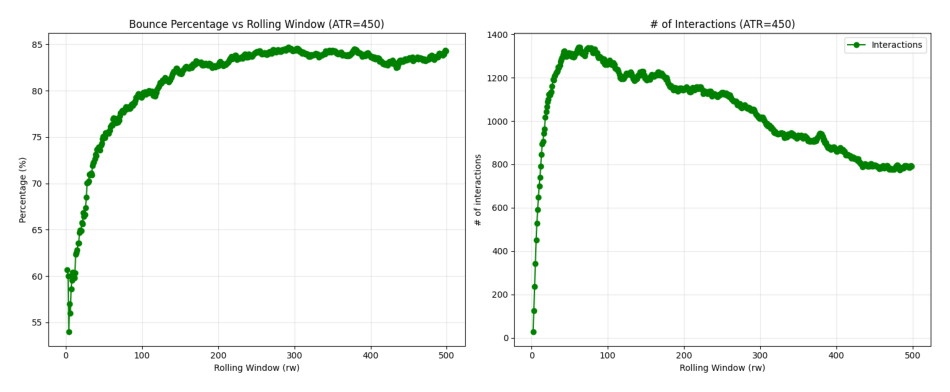

In [13]:
import pandas as pd
freq = '1m'
atr = 450
path = f'/home/ora/Desktop/luma/almaty-lake-capital/bot/strategy/discovery/figures/{atr}/{freq}_bounce_percentage.png'
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.figure(figsize=(12, 8))
# Load the image
img = mpimg.imread(path)

# Display the image
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()